# PCA with the MNIST (digits) dataset

In this notebook, we take the digits $0$ and $1$ from the MNIST dataset and project them onto the two-dimensional subspace spanned by the first two principal components (i.e., the eigenvectors of the two largest eigenvalues of the covariance matrix).

We plot these projections, with the hopes of seeing two clear "blobs" (one for each digit).

Then, we select some vectors from this 2d space (the "latent space"), with some firmly inside a "blob" and some in no man's land, and use them to produce some new images. The hope is that we will produce some images resembling digits, and also some monstrosities.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import pandas as pd

X_data, y_data = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=True)

y_data = y_data.astype(int)
assert (X_data.dtypes == 'int64').all()
assert (y_data.dtypes == 'int32')

zeroes_ones_mask = y_data.isin([0,1])

X_data_01 = X_data[zeroes_ones_mask]
y_data_01 = y_data[zeroes_ones_mask]
print(f"There are {X_data_01.shape[0]} 0s and 1s in the dataset\n")
print("The .head(3) of the features dataframe is as follows:\n")
print(X_data_01.head(3))

There are 14780 0s and 1s in the dataset

The .head(3) of the features dataframe is as follows:

   pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
1       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
6       0       0       0       0       0       0       0       0       0   

   pixel10  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
1        0  ...         0         0         0         0         0         0   
3        0  ...         0         0         0         0         0         0   
6        0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
1         0         0         0         0  
3         0         0         0         0  
6         0         0         0         0  

[3 rows x 784 columns]


So, each row of the dataframe contains the $784$ pixel values (from 0=black to 255=white). 

Let's plot some of the rows (as $28 \times 28$ black and white images).

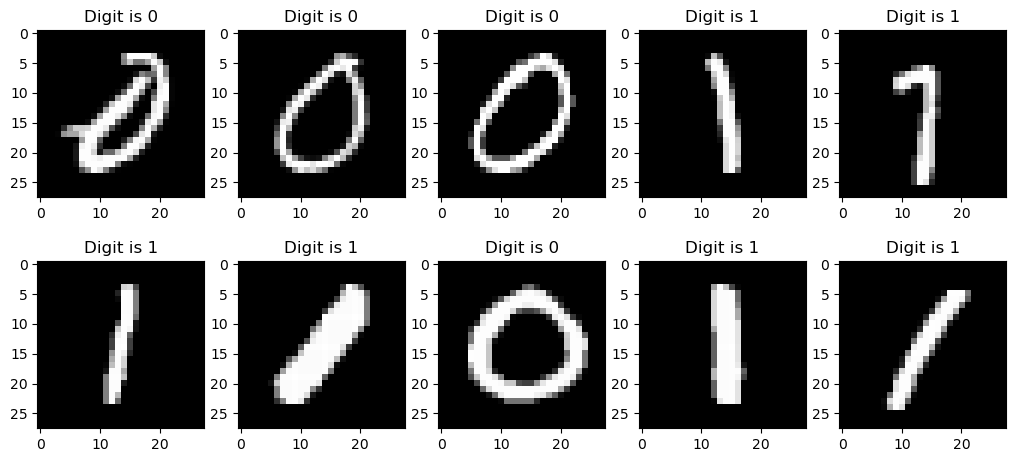

In [5]:
import random 

def plot_digits(image_list: list[list[int]], labels_list: list[int]):
    """
    takes a list of lists of length 28^2 = 784 (the pixels of each image), as well as a list of ints (the labels).
    Reshapes each list of 784 pixels into a 28x28 2d array, and plots the 28x28 image in black and white. 
    0 = black, 255 = white
    """
    grid_rows = (len(image_list)-1)//5 + 1 
    figure = plt.figure(figsize=(12.5, 5.5*(grid_rows-1))) #the height is fiddly... For 2 grid rows, a multiplier of 5.5 looks good.
    for pos, (pixels, label) in enumerate(zip(image_list,labels_list),1):
        plt.subplot(grid_rows,5,pos)
        plt.imshow(pixels.reshape(28,28), cmap='gray', vmin=0, vmax=255)
        plt.title(f"Digit is {label}")
    plt.show()

num_rows = X_data_01.shape[0]
sample_of_row_indices = random.sample(range(num_rows), 10)

sample_of_images = np.array([[X_data_01.iloc[i].values] for i in sample_of_row_indices])
sample_of_labels = [y_data_01.iloc[i] for i in sample_of_row_indices]

plot_digits(sample_of_images,sample_of_labels)

We will need to center the data about the origin $\underline{0} \in \mathbb{R}^{784}$ (that is, subtract the mean of all the rows from each row). 

Then, we require the two eigenvectors with the largest eigenvalues of the covariance matrix, $S$. 

Our data matrix is $X \in \mathbb{R}^{N \times 784}$ with $N >> 784$. The covariance matrix is given by $S = \frac{1}{N} X^TX \in \mathbb{R}^{784 \times 784}$.

In [7]:
mean_of_X_data_01 = np.mean(X_data_01, axis=0) 

X_data_01_centered = X_data_01 - mean_of_X_data_01

C = (X_data_01_centered.T @ X_data_01_centered) / X_data_01_centered.shape[0]

eigenvals, eigenvecs = np.linalg.eigh(C)

PC1, PC2 = eigenvecs[:, -1], eigenvecs[:, -2]

We now have our two eigenvectors. Form the matrix $B^T = \begin{pmatrix} --- & PC1^T & --- \\ --- & PC2^T & --- \end{pmatrix} \in \mathbb{R}^{2 \times 784}$.

Let $r \in \mathbb{R}^{784}$ be a row of `X_data_01_centered` (note: we've implicitly transposed here. $r$ should be considered a column vector). 

Then $B^Tr \in \mathbb{R}^2$ gives the coordinates with respect to $\{PC_1,PC_2\}$ of the $784$ dimensional vector, $r$, projected to $\text{span}\{PC_1,PC_2\}$.

Let us calculate this for each row in our mean-adjusted dataframe, `X_data_01_centered`, and plot the results.

In [9]:
Bt = np.vstack((PC1, PC2))

projected_2d_coords_and_labels = []

for ind,row in X_data_01_centered.iterrows():
    projected_2d_coords_and_labels.append((Bt @ row.values.T, y_data_01[ind]))

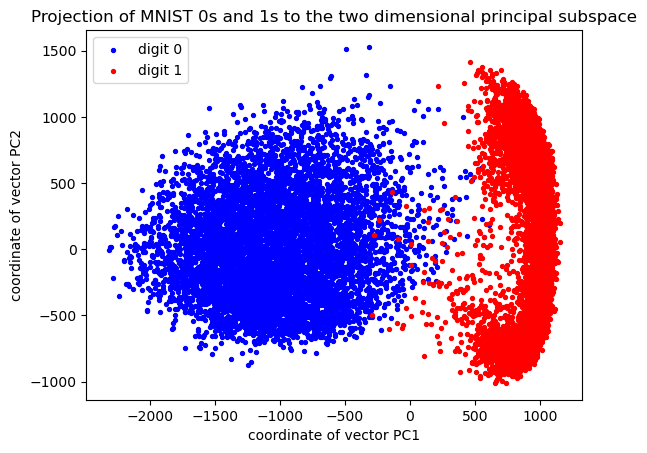

In [10]:
digit_to_colour_map = {0: "blue", 1: "red"}

for n in [0,1]:
    x_coords_labelled_n = [point[0][0] for point in projected_2d_coords_and_labels if point[1] == n]
    y_coords_labelled_n = [point[0][1] for point in projected_2d_coords_and_labels if point[1] == n]
    plt.scatter(x_coords_labelled_n, y_coords_labelled_n, color=digit_to_colour_map[n], label=f'digit {n}',s=8)
plt.legend()
plt.xlabel('coordinate of vector PC1')
plt.ylabel('coordinate of vector PC2')
plt.title('Projection of MNIST 0s and 1s to the two dimensional principal subspace')
plt.show()

Let us choose some $2d$ points, $z$, embed them into $784$-dimensional space via $z \mapsto Bz + \text{mean}$ and plot the resulting $28 \times 28$ image.

The points will be chosen manually (by looking at the above plot).

We pick six points. The first two will be attempts at producing a $28 \times 28$ image resembling a $0$, the next two will be attempts at producing a $28 \times 28$ image resembling a $1$, and finally, the last two will be somewhere in between.

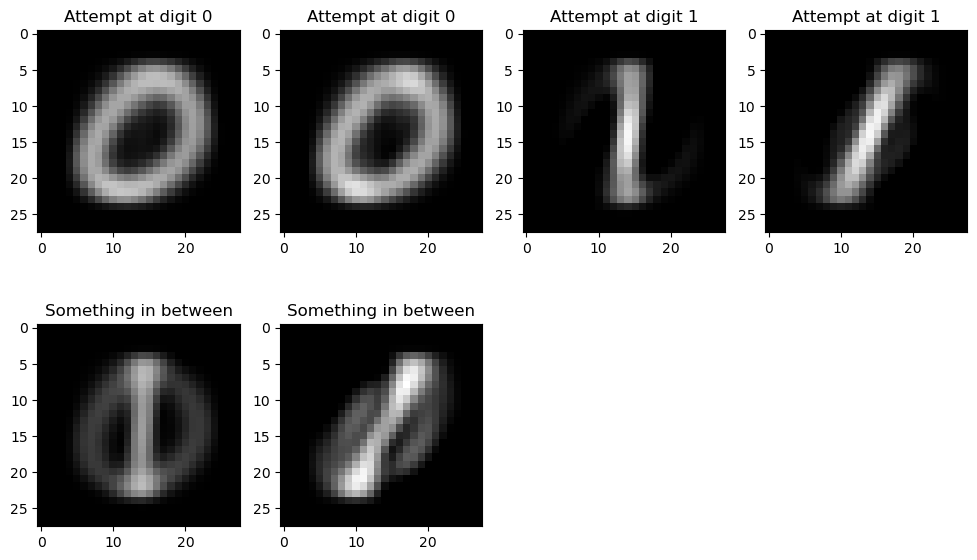

In [12]:
digit0_attempt_1 = (-1000,0)
digit0_attempt_2 = (-1100,200)

digit1_attempt_1 = (1000,-600)
digit1_attempt_2 = (1000,600)

in_between_1 = (200,-500)
in_between_2 = (250,1000)

latent_vectors = [digit0_attempt_1, digit0_attempt_2, digit1_attempt_1, digit1_attempt_2,in_between_1,in_between_2]

def embed_2d_to_784d(vec):
    """
    takes latent vector z, and applies z -> Bz + mean, where B is a 784x2 matrix consisting of the top 2 principal components.
    """
    return Bt.T @ vec + mean_of_X_data_01

embedded_vectors = np.array([embed_2d_to_784d(vec) for vec in latent_vectors])

subplot_titles = {1: "Attempt at digit 0", 2: "Attempt at digit 0",
                  3: "Attempt at digit 1", 4: "Attempt at digit 1",
                  5: "Something in between", 6: "Something in between"}

figure = plt.figure(figsize=(12, 7))
for pos, pixels in enumerate(embedded_vectors,1):
    plt.subplot(2,4,pos)
    plt.imshow(pixels.reshape(28,28), cmap='gray', vmin=0, vmax=255)
    plt.title(subplot_titles[pos])
plt.show()